In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'   #set threads
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'
# Core scverse libraries
import scanpy as sc
import anndata as ad
# Data retrieval
import pandas as pd
#import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
## Batch effect removal 
## harmony
import scanpy.external as sce

sc.settings.verbosity = 0
# Figure parameters
sc.settings.set_figure_params(
    dpi=80,
    dpi_save=300, # resolution of saved figures
    facecolor="white",
    frameon=True,  # draw a frame around the plot
    figsize=(4, 4),
    format='pdf'
                    )
# Global rcParams
plt.rcParams.update({
    'axes.spines.top': True,
    'axes.spines.right': True
})

In [2]:
adata_a=sc.read_h5ad('./10_cytotrace2_拟时序分析/10_after_hb_Gr_subanndata.h5ad')

In [27]:
monocle3_pseudotime=pd.read_csv('./10_cytotrace2_拟时序分析/10_gr_monocle3_pseudotime.csv',index_col=0)
monocle3_pseudotime

,monocle3_pseudotime
GSM8302650_AAACCCAAGGCAATGC-1-GSM8302650,22.869792
GSM8302650_AAACCCACATCGCTGG-1-GSM8302650,34.825380
GSM8302650_AAACCCAGTATGAGAT-1-GSM8302650,9.257256
GSM8302650_AAACCCAGTTTAGACC-1-GSM8302650,31.145866
GSM8302650_AAACGAAAGATGTTGA-1-GSM8302650,14.777969
...,...
GSM8302655_TTTGTTGAGCGGACAT-1-GSM8302655,36.577004
GSM8302655_TTTGTTGAGGGAACAA-1-GSM8302655,9.505513
GSM8302655_TTTGTTGCACGGTGTC-1-GSM8302655,39.601026
GSM8302655_TTTGTTGGTGTTATCG-1-GSM8302655,36.549271


In [ ]:
adata_a.obs_names.equals(monocle3_pseudotime.index)

In [28]:
adata_a.obs['monocle3_pseudotime']=monocle3_pseudotime

In [9]:
import palantir

In [10]:
### Dimensionality reduction
adata_pr=adata_a
har_projections = pd.DataFrame(adata_pr.obsm['X_pca_harmony'], index=adata_pr.obs_names) # batch-corrected embedding
dm_res = palantir.utils.run_diffusion_maps(har_projections, n_components=10)
ms_data = palantir.utils.determine_multiscale_space(dm_res)

In [9]:
adata_a

AnnData object with n_obs × n_vars = 33475 × 18144
    obs: 'sample', 'n_genes', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'bbknn_leiden_0.5', 'harmony_leiden_0.5', 'harmony_leiden_0.2', 'Major_annotation', 'doublet_score', 'predicted_doublet', 'd_harmony_leiden_0.2', 'Major_annotation_d', 'Gr_subannotation', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'dpt_pseudotime', 'Palantir_pseudotime', 'Palantir_DP', 'Branch1', 'Branch2', 'Branch2_cells', 'Branch1_cells', 'monocle3_pseudotime'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts',

In [12]:
## Define the starting cell population
GC_mask = np.isin(adata_a.obs['Gr_subannotation'], ['GC_5']) 
GC_min_stem_id = np.argmin(adata_a.obsm['X_diffmap_'][GC_mask, 1])
print(GC_min_stem_id)
GC_root_id=np.arange(len(GC_mask))[GC_mask][GC_min_stem_id]
print(GC_root_id)

5585
26290


In [ ]:
## Define the terminal cell populations
## Terminal cells chosen from prior knowledge
terminal_cells = {
   har_projections.index[adata_a.obs['Gr_subannotation']  == 'GC_3'][0]: "Branch2",
    har_projections.index[adata_a.obs['Gr_subannotation']  == 'GC_0'][0]: "Branch1"
}

In [ ]:
### Run Palantir inference

early_cell = har_projections.index.tolist()[GC_root_id]
terminal_cell=terminal_cells
pr_res = palantir.core.run_palantir(ms_data
                                    , early_cell=early_cell
                                    , use_early_cell_as_start=False 
                                   ,n_jobs=5
                                    ,terminal_states=terminal_cell
                                    , num_waypoints=500, knn=30)

Sampling and flocking waypoints...
Time for determining waypoints: 0.05834484497706095 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.77765345176061 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9991
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [21]:

### Save results
adata_a.obs['Palantir_pseudotime'] = pr_res.pseudotime
adata_a.obs["Palantir_DP"] = pr_res.entropy


In [22]:
# Rename branch probability columns via the terminal_cell mapping
pr_res.branch_probs.columns= [terminal_cell[col] for col in pr_res.branch_probs.columns]
for i in pr_res.branch_probs.columns.tolist():
    adata_a.obs[i] = pr_res.branch_probs[i]
adata_a.obsm['palantir_fate_probabilities']=pr_res.branch_probs

In [24]:
## Select branch cells
branch_masks=palantir.presults.select_branch_cells(adata_a,pseudo_time_key='Palantir_pseudotime',save_as_df=True)

In [25]:
# Define column and row names
column_names = ['Branch2_cells','Branch1_cells']
row_names = adata_a.obs_names

# Convert to DataFrame
branch_masks_df = pd.DataFrame(branch_masks, columns=column_names, index=row_names)

adata_a.obs[['Branch2_cells','Branch1_cells']]=branch_masks_df

In [26]:
#### Save branch probability data
adata_a.obs[['Branch2','Branch1']]=adata_a.obsm['palantir_fate_probabilities']

In [32]:
### Save results
adata_a.obs.to_csv('./10_cytotrace2_拟时序分析/pseudotime_res_all.csv',index=True)

In [3]:
### Export UMAP coordinates
adata_a.obsm['X_umap']

# Define column and row names
column_names = ['UMAP_1','UMAP_2']
row_names = adata_a.obs_names

# Convert to DataFrame
umap_df = pd.DataFrame(adata_a.obsm['X_umap'], columns=column_names, index=row_names)

### Save results
umap_df.to_csv('./10_cytotrace2_拟时序分析/10_UMAP_coords.csv',index=True)

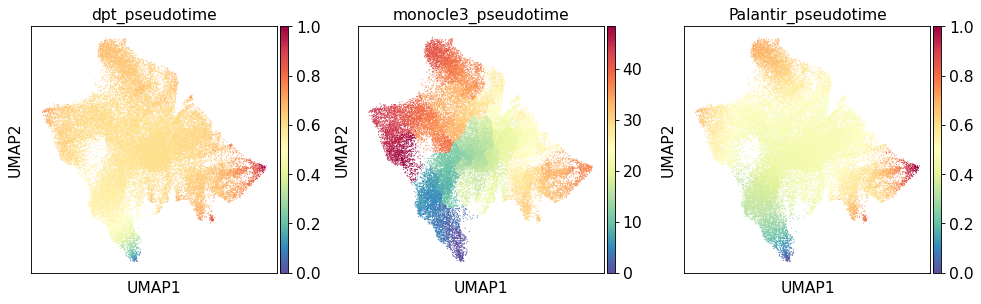

In [36]:
sc.pl.umap(adata_a, color=[ 'dpt_pseudotime','monocle3_pseudotime','Palantir_pseudotime']
               ,frameon=True
           ,legend_fontsize=10
           ,show=False
            ,cmap='Spectral_r'
               )
### Save as PDF
plt.savefig("./figures/10_three_pseudotime.pdf", format="pdf", bbox_inches='tight')

In [37]:
adata_a.write('./10_cytotrace2_拟时序分析/10_after_hb_Gr_subanndata.h5ad')

In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'   #set threads
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'
# Core scverse libraries
import scanpy as sc
import anndata as ad
# Data retrieval
import pandas as pd
#import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
## Batch effect removal 
## harmony
import scanpy.external as sce

sc.settings.verbosity = 0
# Figure parameters
sc.settings.set_figure_params(
    dpi=80,
    dpi_save=300, # resolution of saved figures
    facecolor="white",
    frameon=True,  # draw a frame around the plot
    figsize=(4, 4),
    format='pdf'
                    )
# Global rcParams
plt.rcParams.update({
    'axes.spines.top': True,
    'axes.spines.right': True
})

In [7]:
import omicverse as ov
import scvelo as scv

In [4]:
adata_a=sc.read_h5ad('./10_cytotrace2_拟时序分析/10_after_hb_Gr_subanndata.h5ad')

In [5]:
#### PAGA
ov.utils.cal_paga(adata_a,use_time_prior='Palantir_pseudotime',vkey='paga',
                 groups='Gr_subannotation')

running PAGA using priors: ['Palantir_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


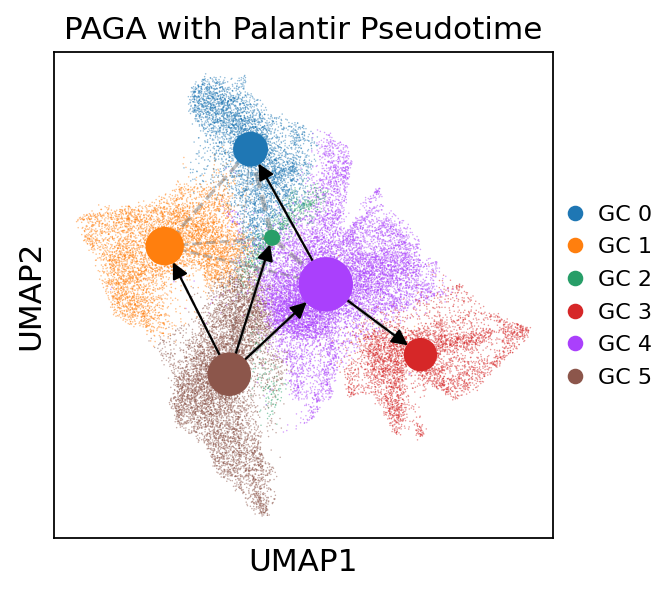

In [8]:
scv.pl.paga(adata_a,basis='umap'
           #,threshold=0.03
            ,node_size_scale=1.5
            ,min_edge_width=1
    ,edge_width_scale=2
    ,node_size_power=1
    ,add_pos=True,
    title='PAGA with Palantir Pseudotime'
    ,frameon=True
    ,legend_fontsize=10
    , layout='fr'
    ,labels=None
    ,show=False
    ,figsize=(4,4)
           )

### Save as PDF
plt.savefig("./figures/10_PAGA_Palantir_plots.pdf", format="pdf", bbox_inches='tight')